In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_and_preprocess_nab(directory_path, resample_rate='5T'):
    """
    Loads multiple NAB CSVs, handles overlapping indices,
    and aligns them to a common timestamp grid.
    """
    all_files = glob.glob(os.path.join(directory_path, "*.csv"))
    processed_dfs = []

    for file in all_files:
        # 1. Extract Unique ID from filename (e.g., 'ec2_cpu_utilization_5f5533')
        metric_id = os.path.basename(file).replace('.csv', '')

        df = pd.read_csv(file)
        df['timestamp'] = pd.to_datetime(df['timestamp'])

        # 2. Handle duplicates within a single file if they exist
        df = df.drop_duplicates(subset='timestamp')
        df = df.set_index('timestamp').sort_index()

        # 3. Resample to align with other files (e.g., floor to nearest 5 mins)
        # This solves the 14:27 vs 14:25 alignment issue
        df = df.resample(resample_rate).mean()

        # Rename 'value' to the unique filename ID
        df = df.rename(columns={'value': metric_id})
        processed_dfs.append(df)

    # 4. Merge all files. Using 'join' on the index (timestamp)
    # We use a list-based concat to handle multiple columns efficiently
    final_df = pd.concat(processed_dfs, axis=1)

    # 5. Handle missing values generated by the outer join/resampling
    # Limit linear interpolation to avoid creating data where there's a huge gap
    final_df = final_df.interpolate(method='time', limit=3).fillna(0)

    return final_df

# Path from your screenshot
path = "realAWSCloudwatch"
df_final = load_and_preprocess_nab(path)

print(f"Merged Columns: {df_final.columns.tolist()[:5]} ...")
print(df_final.head())

/var/folders/zl/bj746_7n1td1n16bmn9b0zn40000gn/T/ipykernel_3680/1100089748.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample(resample_rate).mean()
/var/folders/zl/bj746_7n1td1n16bmn9b0zn40000gn/T/ipykernel_3680/1100089748.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample(resample_rate).mean()
/var/folders/zl/bj746_7n1td1n16bmn9b0zn40000gn/T/ipykernel_3680/1100089748.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample(resample_rate).mean()
/var/folders/zl/bj746_7n1td1n16bmn9b0zn40000gn/T/ipykernel_3680/1100089748.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample(resample_rate).mean()
/var/folders/zl/bj746_7n1td1n16bmn9b0zn40000gn/T/ipykernel_3680/1100089748.py:22: FutureWarning: 'T' is depr

Merged Columns: ['ec2_cpu_utilization_825cc2', 'ec2_network_in_257a54', 'ec2_cpu_utilization_c6585a', 'rds_cpu_utilization_cc0c53', 'ec2_cpu_utilization_5f5533'] ...
                     ec2_cpu_utilization_825cc2  ec2_network_in_257a54  \
timestamp                                                                
2013-10-09 16:25:00                         0.0                    0.0   
2013-10-09 16:30:00                         0.0                    0.0   
2013-10-09 16:35:00                         0.0                    0.0   
2013-10-09 16:40:00                         0.0                    0.0   
2013-10-09 16:45:00                         0.0                    0.0   

                     ec2_cpu_utilization_c6585a  rds_cpu_utilization_cc0c53  \
timestamp                                                                     
2013-10-09 16:25:00                         0.0                         0.0   
2013-10-09 16:30:00                         0.0                         0.0   

--- Missing Data Percentage per Metric ---
Series([], dtype: float64)


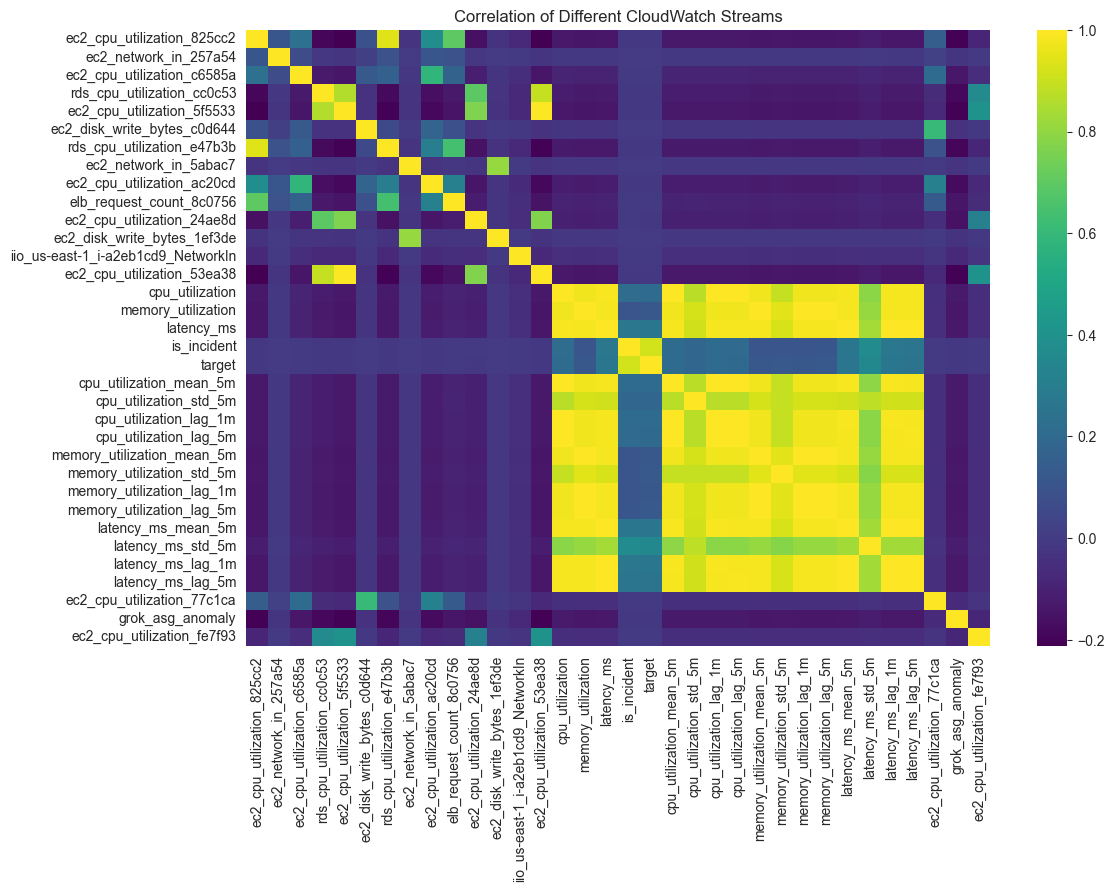

In [3]:
def analyze_availability(df):
    """Checks for data sparsity after merging."""
    missing_pct = df.isnull().mean() * 100
    print("--- Missing Data Percentage per Metric ---")
    print(missing_pct[missing_pct > 0])

    # Plotting a heatmap of correlations to see which metrics move together
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), cmap='viridis')
    plt.title("Correlation of Different CloudWatch Streams")
    plt.show()

analyze_availability(df_final)

In [42]:
import pandas as pd
import numpy as np

def label_anomalies_zscore(df, anomaly_csv_path, value_col='grok_asg_anomaly', threshold=3):
    """
    Labels anomalies using:
    1. The ground truth CSV
    2. Any value more than 'threshold' standard deviations from the mean
    """
    # 1. Ground Truth from CSV
    anomaly_df = pd.read_csv(anomaly_csv_path)
    anomaly_df['timestamp'] = pd.to_datetime(anomaly_df['timestamp'])

    df['is_anomaly'] = 0
    # anomaly_timestamps = anomaly_df['timestamp'].dt.round('5T')
    # df.loc[df.index.isin(anomaly_timestamps), 'is_anomaly'] = 1

    # 2. Standard Deviation Logic
    mean_val = df[value_col].mean()
    std_val = df[value_col].std()

    # Calculate how many standard deviations each point is from the mean
    # Formula: z = (x - mean) / std
    z_scores = (df[value_col] - mean_val) / std_val

    # Label as anomaly if the absolute Z-score is greater than our threshold
    # (This catches both massive spikes and massive drops)
    # df.loc[z_scores.abs() > threshold, 'is_anomaly'] = 1
    df.loc[(df[value_col] > 0) & (df[value_col] < 30), 'is_anomaly'] = 1
    print(f"Mean: {mean_val:.2f}, Std Dev: {std_val:.2f}")
    print(f"Total anomalies labeled: {df['is_anomaly'].sum()}")
    print(len(df))

    return df

# Usage
# threshold=3 is standard; use 2 if you want to be more sensitive
df_labeled = label_anomalies_zscore(df_final, "realAWSCloudwatch/grok_asg_anomaly.csv")

Mean: 5.61, Std Dev: 12.60
Total anomalies labeled: 432
22815


In [57]:
import pandas as pd

def create_sliding_window(df, W=12, H=3):
    """
    W = window size (history)
    H = horizon (future)
    """
    # 1. Feature Engineering: Extract Time Components
    # Assuming df.index is a DatetimeIndex. If not, convert it first:
    # df.index = pd.to_datetime(df.index)
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['minute'] = df.index.minute

    # 2. Identify columns to use
    # Exclude targets and the "leaky" column you found earlier
    exclude = ['is_anomaly', 'grok_asg_anomaly']
    feature_cols = [c for c in df.columns if c not in exclude]

    data_values = df[feature_cols].values
    anomaly_values = df['is_anomaly'].values

    features = []
    targets = []

    for i in range(len(df) - W - H):
        # Slice the window
        window = data_values[i : i + W] # Shape (W, num_features)

        # --- FEATURE EXTRACTION PER WINDOW ---

        # A. Raw flattened values (The "What happened")
        raw_flat = window.flatten()

        # B. Statistical Features (The "How weird is it")
        # Mean and Std Dev for each metric in this window
        means = np.mean(window, axis=0)
        stds = np.std(window, axis=0)

        # C. Delta/Change (The "How fast is it moving")
        # Difference between the last value and the first value in the window
        diff = window[-1] - window[0]

        # Combine everything into one long feature vector for this sample
        sample_features = np.concatenate([raw_flat, means, stds, diff])

        features.append(sample_features)

        # Target: 1 if ANY anomaly occurs in the next H steps
        future_window = anomaly_values[i + W : i + W + H]
        targets.append(1 if np.any(future_window == 1) else 0)

    return np.array(features), np.array(targets)

# Re-run the transformation
# X, y = create_sliding_window(df_labeled, W=12, H=3)
# print(f"New X shape: {X.shape} (Each sample now has more descriptive features!)")

# Let's say we look at the last 1 hour (W=12) to predict the next 15 mins (H=3)
X, y = create_sliding_window(df_labeled, W=12, H=3)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (22800, 540), y shape: (22800,)


--- Fold 1 Results ---
              precision    recall  f1-score   support

           0       0.77      0.99      0.87      2939
           1       0.10      0.00      0.01       861

    accuracy                           0.77      3800
   macro avg       0.44      0.50      0.44      3800
weighted avg       0.62      0.77      0.67      3800


Average F1-Score across all folds: 0.0089


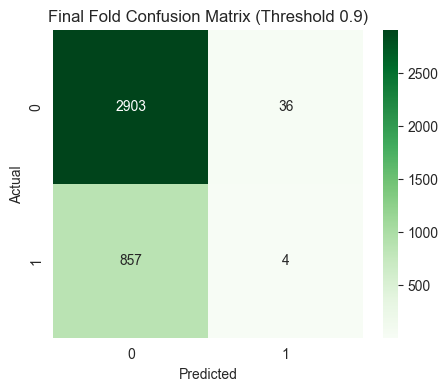

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

tscv = TimeSeriesSplit(n_splits=5)
all_f1_scores = []

# To keep track of the final model for importance plotting
final_model = None
final_X_test = None
final_y_test = None

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    if sum(y_train) > 0 and sum(y_test) > 0:
        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        # Use probability thresholding
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs > 0.5).astype(int)

        print(f"--- Fold {i+1} Results ---")
        print(classification_report(y_test, y_pred, zero_division=0))

        all_f1_scores.append(f1_score(y_test, y_pred))

        # Keep the last fold's data for the final visualization
        final_model = model
        final_cm = confusion_matrix(y_test, y_pred)
        final_X_test = X_test
        final_y_test = y_test

print(f"\nAverage F1-Score across all folds: {np.mean(all_f1_scores):.4f}")

# Visualize Final Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Final Fold Confusion Matrix (Threshold 0.9)")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
!brew install libomp

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
apkeep: Command-line tool for downloading APK files from various sources
atuin-server: Sync server for atuin - Improved shell history for zsh, bash, fish and nushell
buildkitd: Concurrent, cache-efficient, and Dockerfile-agnostic builder toolkit (Daemon)
checkpwn: Check Have I Been Pwned and see if it's time for you to change passwords
cloudflare-speed-cli: Cloudflare-based speed test with optional TUI
dlpack: Common in-memory tensor structure
docker-engine: Pack, ship and run any application as a lightweight container (Daemon)
flowrs: TUI application for Apache Airflow
git-pkgs: Track package dependencies across git history
gittype: CLI code-typing game that turns your source code into typi


--- Fold 1 Results ---
              precision    recall  f1-score   support

           0       0.76      0.84      0.80      2939
           1       0.16      0.11      0.13       861

    accuracy                           0.67      3800
   macro avg       0.46      0.47      0.46      3800
weighted avg       0.63      0.67      0.65      3800


Average F1-Score across all folds: 0.1285


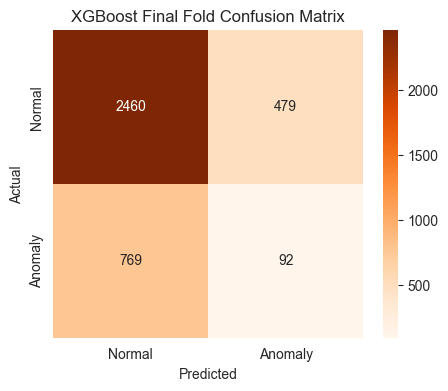

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
all_f1_scores = []

final_model = None
final_cm = None

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    if sum(y_train) > 0 and sum(y_test) > 0:
        # Calculate class imbalance ratio for XGBoost
        # This tells the model to pay 'ratio' times more attention to anomalies
        ratio = (len(y_train) - sum(y_train)) / sum(y_train)

        # 2. Initialize and Train XGBoost
        model = XGBClassifier(
            n_estimators=300,        # More trees to find complex patterns
            learning_rate=0.03,      # Slower learning
            max_depth=8,             # Deeper trees to capture interactions
            scale_pos_weight=ratio * 10, # Push the weight even higher
            gamma=1,                 # Prevents overfitting
            eval_metric='aucpr',     # Optimize for Precision-Recall Area Under Curve
            random_state=42
        )

        model.fit(X_train, y_train)

        # 3. Predict with Probability Thresholding
        # Using 0.5 as a baseline, but you can increase it to 0.7 or 0.8
        # if you get too many False Positives.
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs > 0.01).astype(int)

        print(f"\n--- Fold {i+1} Results ---")
        print(classification_report(y_test, y_pred, zero_division=0))

        all_f1_scores.append(f1_score(y_test, y_pred))

        # Capture the last fold for visualization
        final_model = model
        final_cm = confusion_matrix(y_test, y_pred)
        current_X_test = X_test
        current_y_test = y_test

print(f"\nAverage F1-Score across all folds: {np.mean(all_f1_scores):.4f}")

# 4. Final Confusion Matrix Visualization
plt.figure(figsize=(5,4))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title("XGBoost Final Fold Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

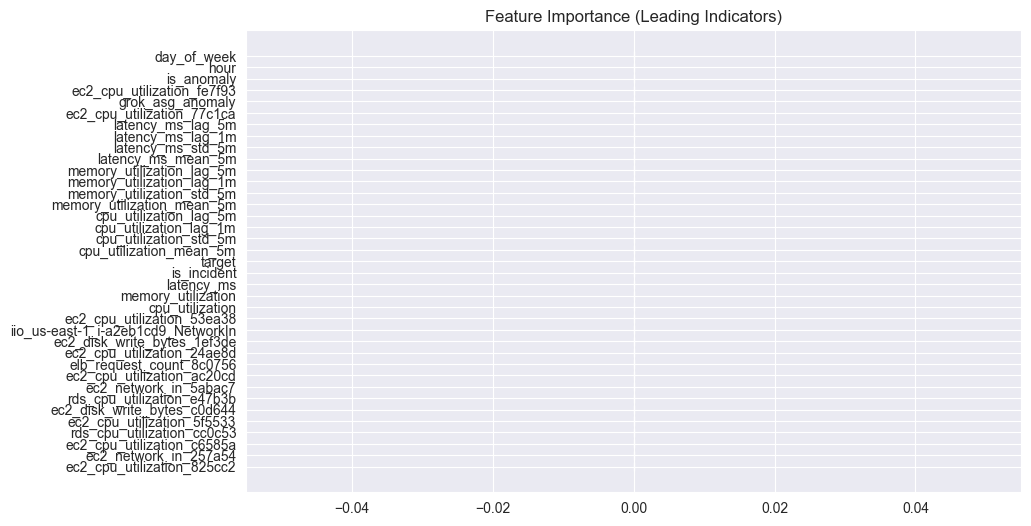

In [49]:
# Assuming 'feature_cols' is the list of your metric names from earlier
# Because we flattened the window, we have (W * num_metrics) features.
importances = model.feature_importances_
# Just looking at the most recent time step's importance for simplicity
num_metrics = len(df_final.columns) - 1
latest_step_importances = importances[-num_metrics:]

plt.figure(figsize=(10,6))
plt.barh(df_final.columns[:-1], latest_step_importances)
plt.title("Feature Importance (Leading Indicators)")
plt.show()

In [18]:
import numpy as np
print(f"Total samples: {len(y)}")
print(f"Anomaly samples: {np.sum(y)}")
print(f"Normal samples: {len(y) - np.sum(y)}")


Total samples: 22800
Anomaly samples: 4623
Normal samples: 18177
